# Исследование ассемблерных оптимизаций на примере хэш-таблиц

## Подбор хэш-функции

Для начала нам нужно выбрать хэш функцию. Для этого мы построим хэш-таблицу на примерно 4957 элементов и будем класть в нее ~20000 слов. После этого посмотрим на распределение элементов по корзинам.

### Хэш функция - длина строки

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

df = pd.read_csv("hash_func_choose/test_hashes/result.csv",  sep=";")

df.head()

,hash_func,bucket,size
0,hash_length,0,0
1,hash_length,1,36
2,hash_length,2,139
3,hash_length,3,687
4,hash_length,4,2108


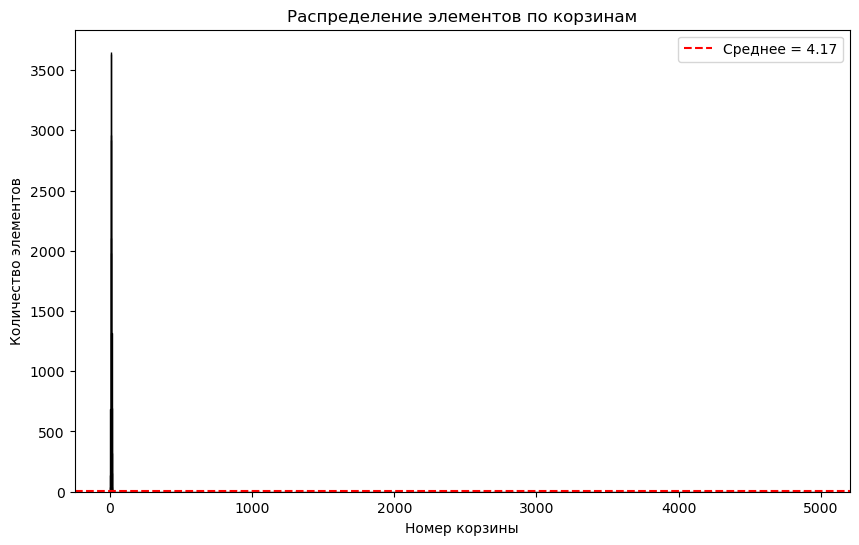

Среднее значение: 4.17
Дисперсия распределения: 11094.51
Стандартное отклонение: 105.33


In [2]:
filtered = df[df["hash_func"] == "hash_length"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

#### Посмотрим на график чуть ближе

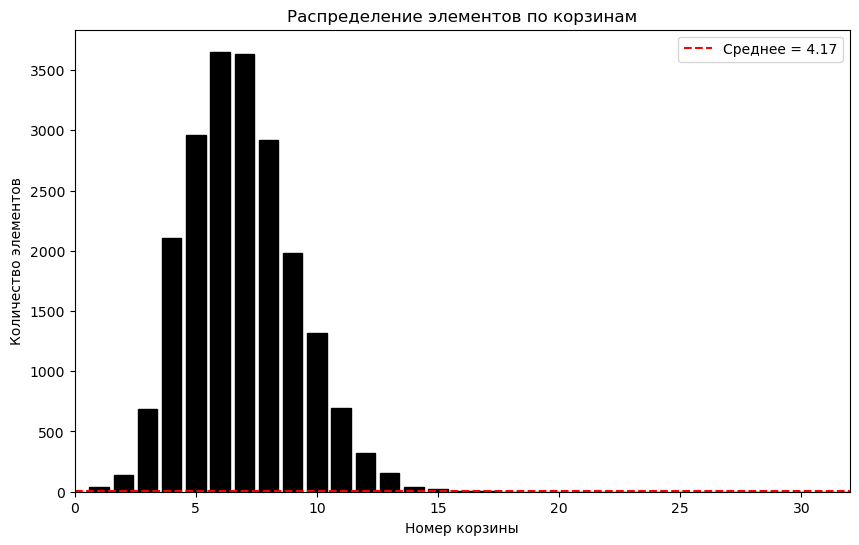

In [264]:
plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()

plt.xlim(0, 32)
plt.show()

In [22]:
from scipy.stats import chisquare

stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 4940.197011460901
p-value: 0.5604857284085168


### Хэш функция - первая буква слова

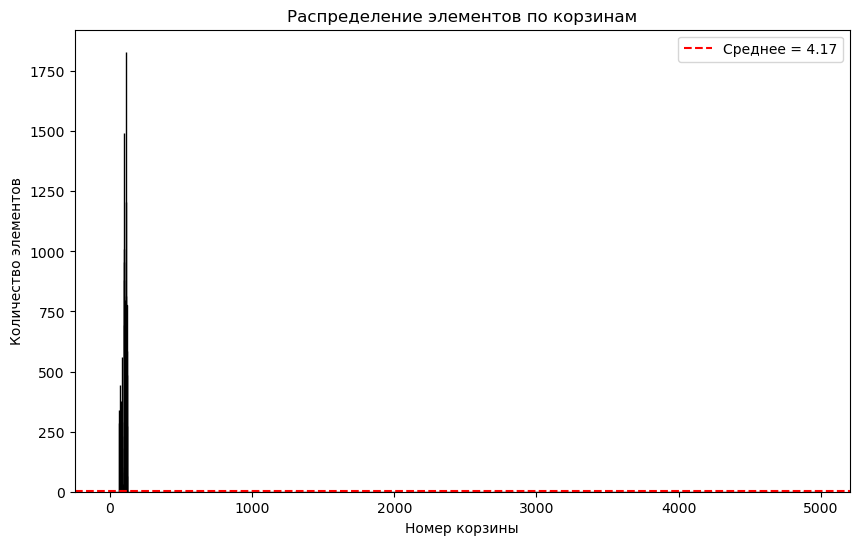

Среднее значение: 4.17
Дисперсия распределения: 3248.38
Стандартное отклонение: 56.99


In [4]:
filtered = df[df.iloc[:,0] == "hash_first_letter"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

#### Посмотрим на график чуть ближе

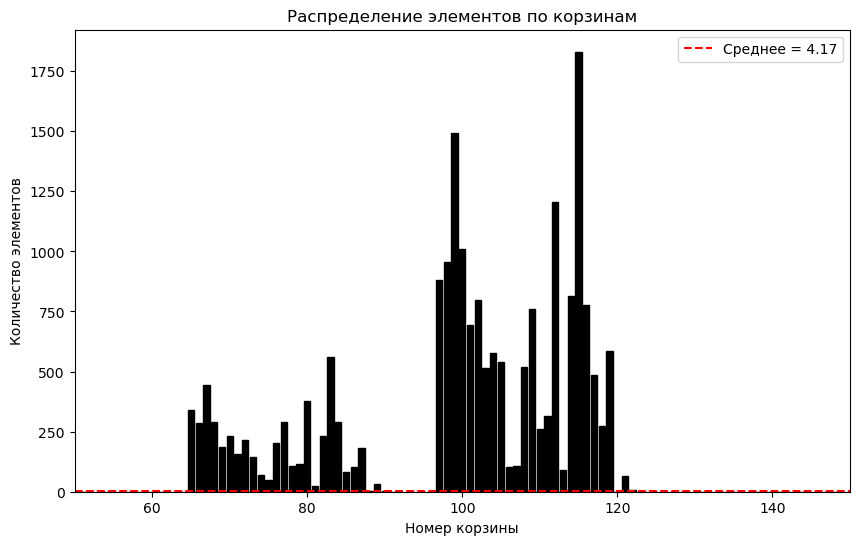

In [5]:
plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()

plt.xlim(50, 150)
plt.show()

In [6]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 3859115.9268823434
p-value: 0.0


### Хэш функция - сумма букв в слове

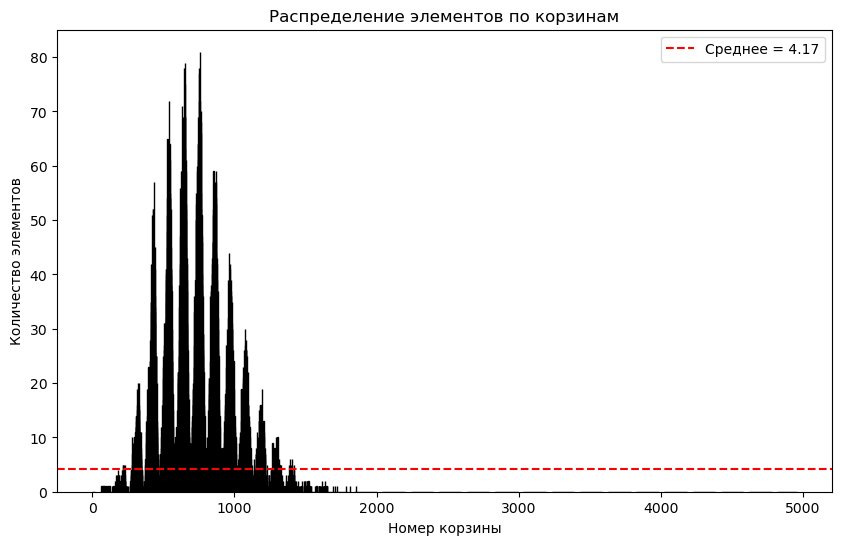

Среднее значение: 4.17
Дисперсия распределения: 131.95
Стандартное отклонение: 11.49


In [7]:
filtered = df[df.iloc[:,0] == "hash_sum_letters"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

#### Посмотрим на график чуть ближе

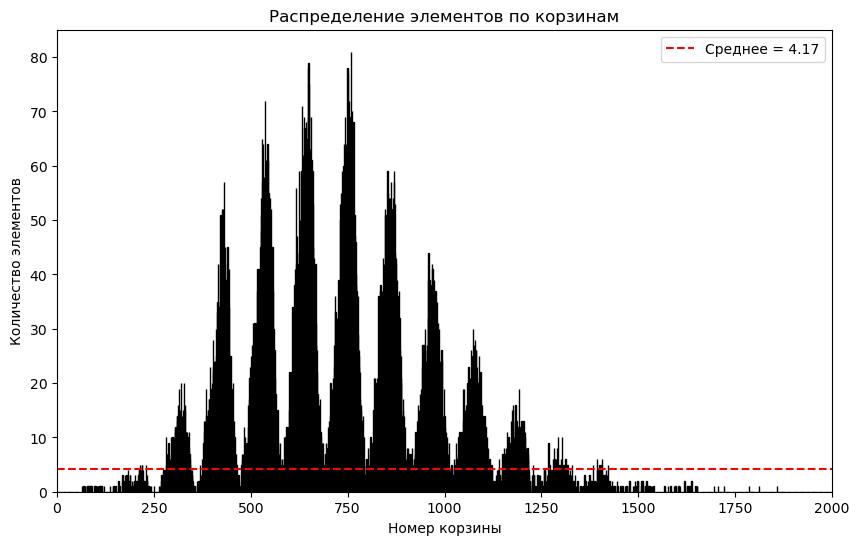

In [8]:
plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()

plt.xlim(0, 2000)
plt.show()

In [9]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 156760.21770878672
p-value: 0.0


### Хэш функция - полиномиальный хэш

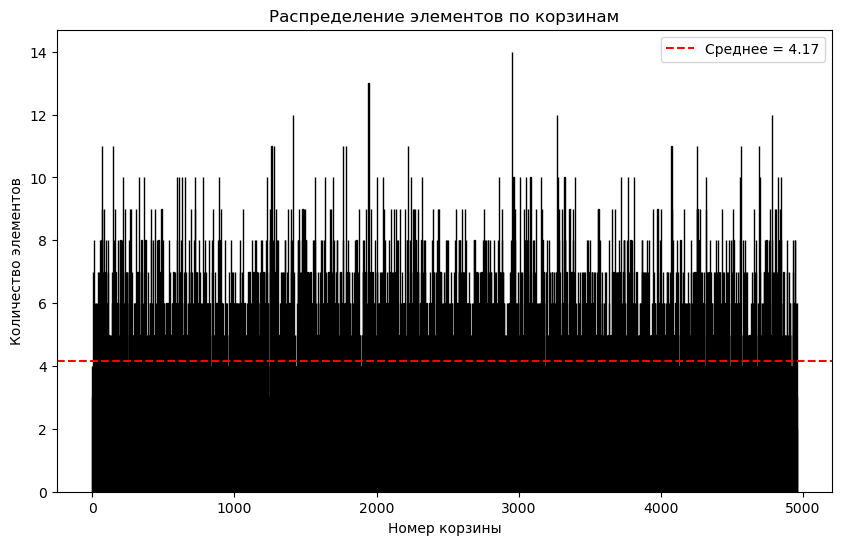

Среднее значение: 4.17
Дисперсия распределения: 4.11
Стандартное отклонение: 2.03


In [10]:
filtered = df[df.iloc[:,0] == "hash_polynomial"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

In [11]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 4883.145606654093
p-value: 0.7669022462332569


### Хэш функция - crc32

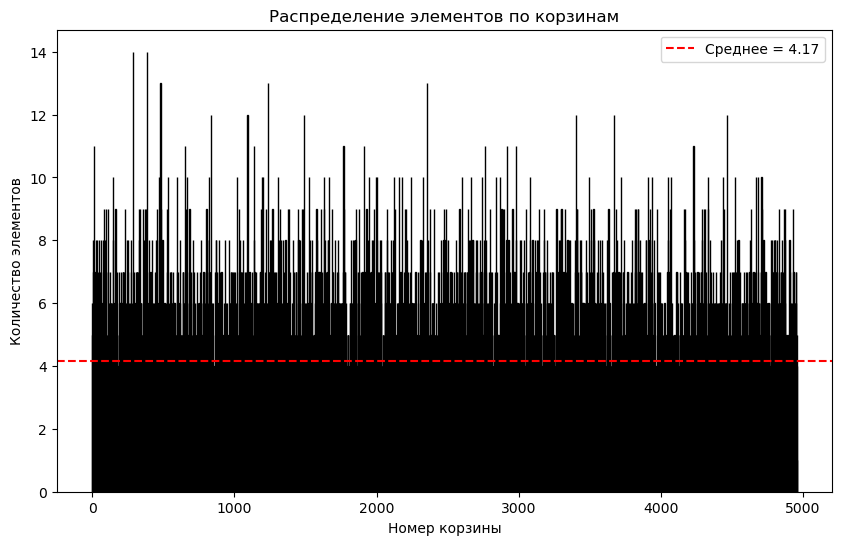

Среднее значение: 4.17
Дисперсия распределения: 4.17
Стандартное отклонение: 2.04


In [12]:
filtered = df[df.iloc[:,0] == "hash_crc32"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

In [13]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 4950.26490642681
p-value: 0.5203094642855284


### Хэш функция - Jenkins hash function

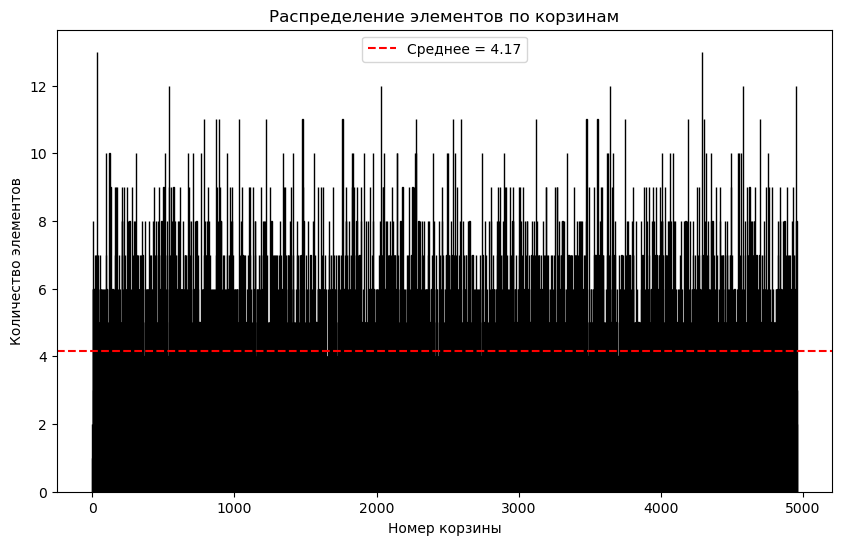

Среднее значение: 4.17
Дисперсия распределения: 4.21
Стандартное отклонение: 2.05


In [14]:
filtered = df[df.iloc[:,0] == "hash_jenkins_one_at_a_time32"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

In [15]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 5004.919193384592
p-value: 0.3097912926815328


### Хэш функция - PJW hash / ELF hash

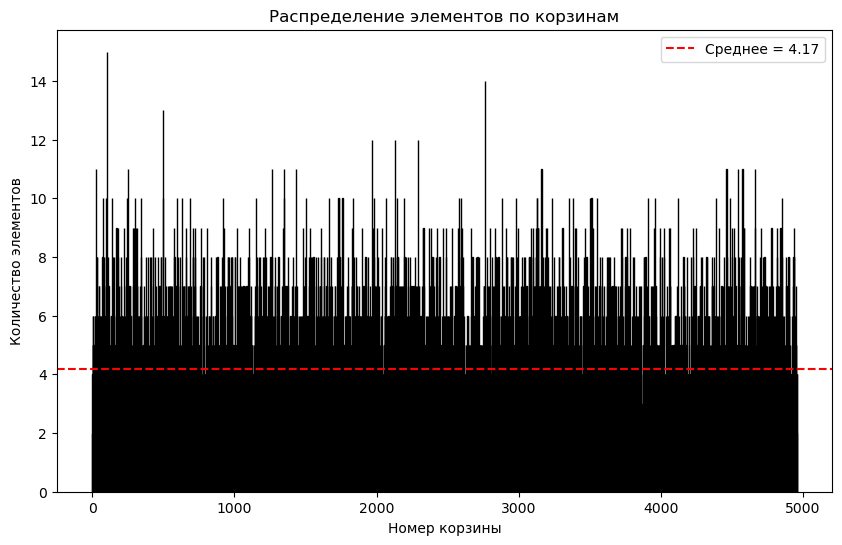

Среднее значение: 4.17
Дисперсия распределения: 4.18
Стандартное отклонение: 2.04


In [16]:
filtered = df[df.iloc[:,0] == "elf_hash"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

In [17]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 4964.647613520963
p-value: 0.46275159444870345


### Хэш функция - FNV1 hash

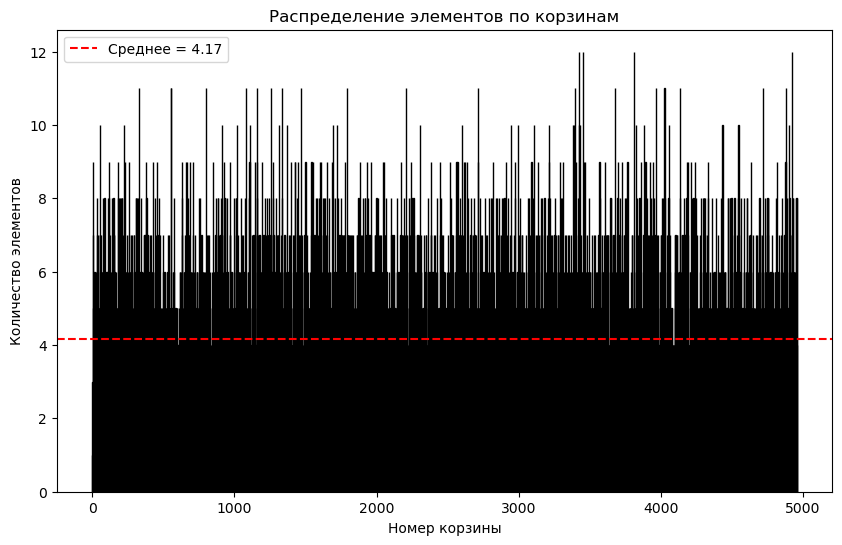

Среднее значение: 4.17
Дисперсия распределения: 4.13
Стандартное отклонение: 2.03


In [18]:
filtered = df[df.iloc[:,0] == "fnv1a_hash"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

In [19]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 4904.240243725519
p-value: 0.6967266417276438


### Хэш функция - Murmur3Hash

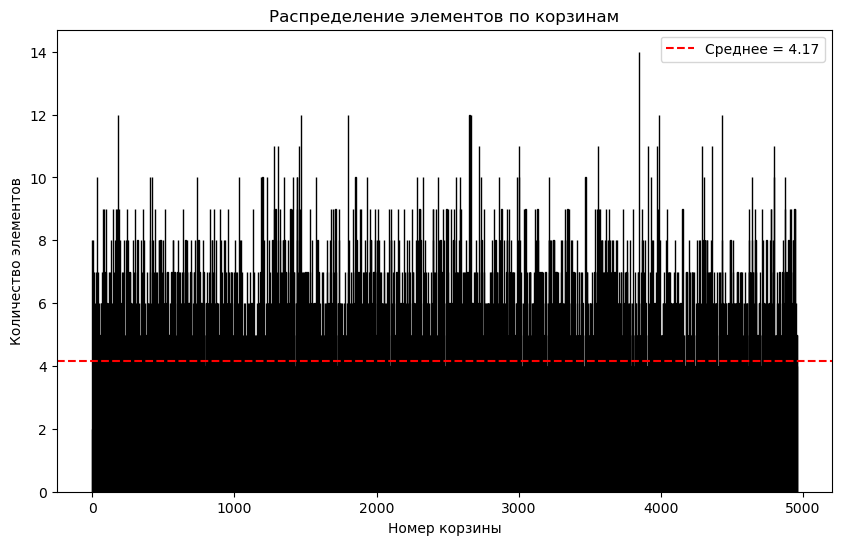

Среднее значение: 4.17
Дисперсия распределения: 4.16
Стандартное отклонение: 2.04


In [20]:
filtered = df[df.iloc[:,0] == "murmur3_hash"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

In [21]:
stat, p = chisquare(counts)

print("chi2:", stat)
print("p-value:", p)


chi2: 4940.197011460901
p-value: 0.5604857284085168


### Сравнение всех хэш функций

| Хэш-функция | Дисперсия количества элементов | p-value |
|--------|------|------|
| hash_length     | 11094.51  | 0.0 |
| hash_first_letter      | 3248.38   | 0.0 |
| hash_sum_letters      | 131.95 | 0.0 |
| hash_polynomial      | 4.11  | 0.77 |
| hash_crc32     | 4.17 | 0.52 |
| hash_jenkins_one_at_a_time32      | 4.21 | 0.31 |
| elf_hash     | 4.18 | 0.46 |
| fnv1a_hash      | 4.13 | 0.70 |
| murmur3_hash      | 4.16 | 0.56 |

Лучше всего себя показали хэш-функция hash_polynomial, поэтому для дальнейших рассчетов будем брать ее.

# Оптимизация хэш таблиц

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


In [55]:
df = pd.read_csv("results.csv", header=None, sep=";")

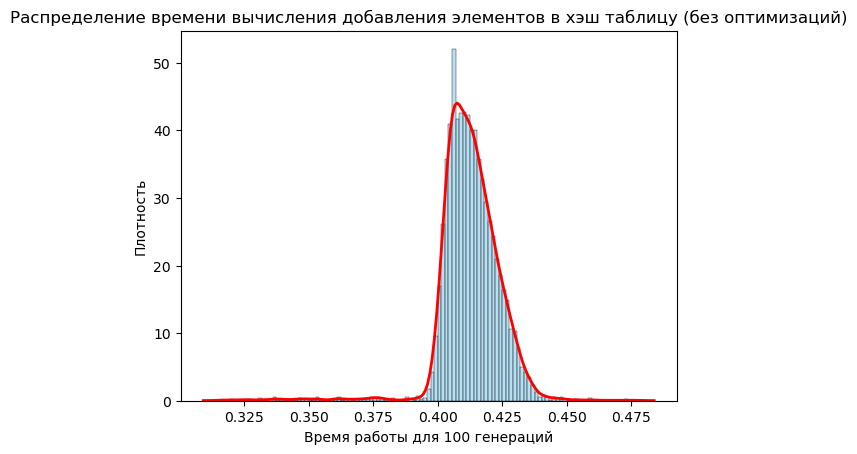

In [26]:
filtered0 = df[df.iloc[:,0] == "opt0"]

sns.histplot(
    data=filtered0,
    x=filtered0.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6,
)

sns.kdeplot(
    data=filtered0,
    x=filtered0.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (без оптимизаций)")
plt.show()

In [27]:
filtered0.describe()

,1
count,6000.000000
mean,0.412743
std,0.011503
min,0.315119
25%,0.406422
50%,0.412185
75%,0.419102
max,0.477875


In [28]:
mean = np.mean(filtered0.iloc[:,1])
std = np.std(filtered0.iloc[:,1], ddof=1)
n = len(filtered0.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print(z * std / np.sqrt(n))

print("Доверительный интервал:")
print(lower, upper)


0.0002910607620060995
Доверительный интервал:
0.41245184723799394 0.4130339687620061


#### Среднее время работы версии без оптимизаций 0.41 (+- 0.01) секунда

#### Посмотрим, где программа тратит больше всего времени через профилировщик valgrind с плагином callgrind


<img src="images_vlgrnd/Screenshot_20260421_230629.png" width="60%">

Хэш таблица получилась довольно-таки cache friendly и оптимизировать использование кэшей не стоит.


<img src="images_vlgrnd/Screenshot_20260423_124706.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260421_230740.png" width="60%">


Видим, что больше всего времени программа проводит на подсчете хэша. Попробуем его оптимизировать, считая хэш для нескольких символов одновременно. Но используя полиномиальных хэш это не получится, так как на каждой итерации цикла итоговый хэш умножается на p и к нему прибавляется текущий символ. Но есть функция, для которой существует intrinsic, позволяющий считать хэш сразу для блока данных и которая показала довольно-таки хорошую дисперсию - это хэш функция crc32. Будем использовать ее

## Оптимизация 1 - замена хэш функции

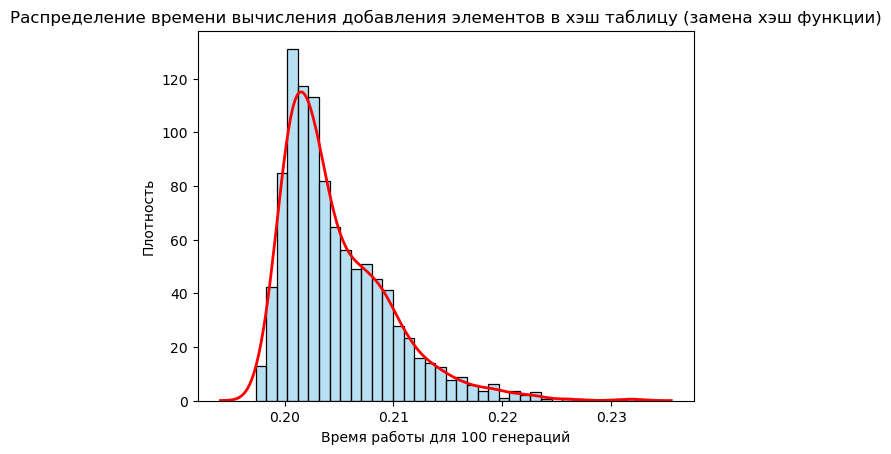

In [29]:
filtered1 = df[df.iloc[:,0] == "opt1"]

sns.histplot(
    data=filtered1,
    x=filtered1.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered1,
    x=filtered1.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (замена хэш функции)")
plt.show()

In [30]:
filtered1.describe()

,1
count,2000.000000
mean,0.204723
std,0.004911
min,0.197331
25%,0.201123
50%,0.203288
75%,0.207348
max,0.232301


In [31]:
mean = np.mean(filtered1.iloc[:,1])
std = np.std(filtered1.iloc[:,1], ddof=1)
n = len(filtered1.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)


lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print(z * std / np.sqrt(n))

print("Доверительный интервал:")
print(lower, upper)

0.00021524905678216812
Доверительный интервал:
0.20450772794321787 0.2049382260567822


### Среднее время работы версии с оптимизацией в виде замены хэш функции 0.203 (+- 0.007) секунд

### Посмотрим где теперь программа тратит больше всего времени

<img src="images_vlgrnd/Screenshot_20260423_125019.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260421_231736.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260427_123721.png" width="60%">

Видим, что больше всего времени тратиться в функции 
```c
int find_node(bucket_t* bucket, const uint32_t hash, const char* key)
```

Видим что большую часть времени функция проводит внутри себя. Возможно, это связано с тем, что для каждого узла в цепочке нужно сравнить хэш, а если хэш совпал, то затем и сам ключ. Однако можно ускорить - давайте будем сравнивать хэш одновременно для 8 ключей, а если ключей в некоторой ячейке больше 8, то будем уже сравнивать хэш по отдельности для каждого ключа. Для реализации этого напишем ассемберную вставку

## Оптимизация 2 - ускорение find_node

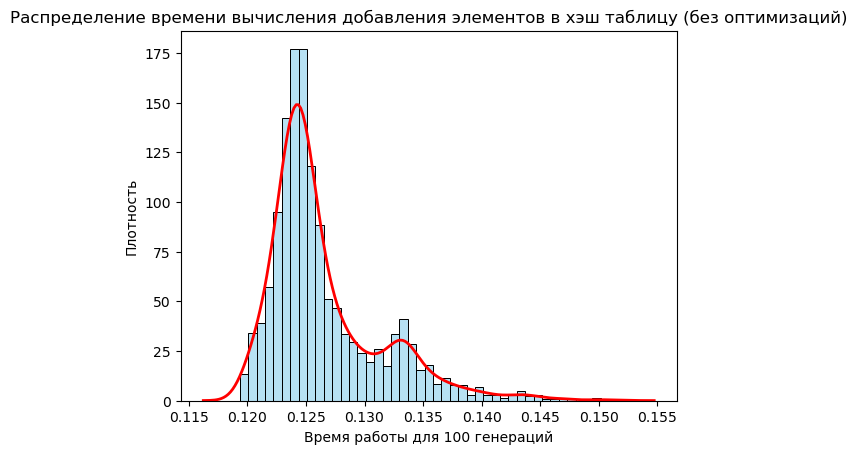

In [32]:
filtered2 = df[df.iloc[:,0] == "opt2"]

sns.histplot(
    data=filtered2,
    x=filtered2.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered2,
    x=filtered2.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (без оптимизаций)")
plt.show()

In [33]:
filtered2.describe()

,1
count,2000.000000
mean,0.126496
std,0.004762
min,0.119360
25%,0.123521
50%,0.124899
75%,0.128121
max,0.151611


In [34]:
mean = np.mean(filtered2.iloc[:,1])
std = np.std(filtered2.iloc[:,1], ddof=1)
n = len(filtered2.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print(z * std / np.sqrt(n))

print("Доверительный интервал:")
print(lower, upper)

0.00020870189074774989
Доверительный интервал:
0.12628699610925226 0.12670439989074778


### Среднее время работы версии с оптимизацией в виде замены хэш функции 0.12 (+- 0.01) секунд

### Посмотрим где теперь программа тратит больше всего времени

<img src="images_vlgrnd/Screenshot_20260423_125248.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260421_232310.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260427_124153.png" width="60%">

Видим, что больше всего времени по прежнему тратиться в функции 
```c
int find_node(bucket_t* bucket, const uint32_t hash, const char* key)
```

Но если посмотреть на эту функцию, можно заметить, что довольно-таки часто вызывается strcmp. Она работает довольно-таки медленно, так как написана для общего случая, но в нашем случае все строки размером 32 байта, и ложатся в ymm регистры, где можно сравнить данные регистры и получить данные о совпадении( также нам не нужно знать, какая строка длиннее или короче, нам нужно знать только совпадают строки или нет).


## Оптимизация 3 - my_strcmp()

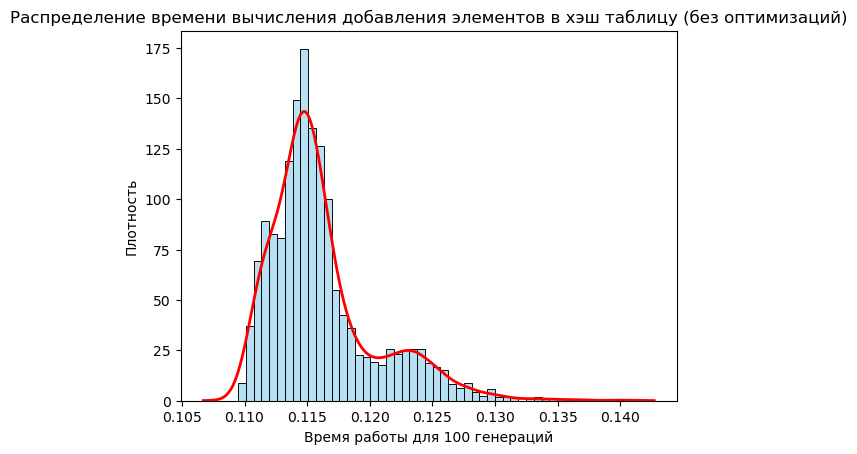

In [35]:
filtered3 = df[df.iloc[:,0] == "opt3"]

sns.histplot(
    data=filtered3,
    x=filtered3.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered3,
    x=filtered.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (без оптимизаций)")
plt.show()

In [ ]:
filtered3.describe()

,1
count,2000.000000
mean,0.116093
std,0.004239
min,0.109489
25%,0.113424
50%,0.115060
75%,0.117353
max,0.139913


In [36]:
mean = np.mean(filtered3.iloc[:,1])
std = np.std(filtered3.iloc[:,1], ddof=1)
n = len(filtered3.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print(z * std / np.sqrt(n))

print("Доверительный интервал:")
print(lower, upper)

0.000185780274619575
Доверительный интервал:
0.11590737972538044 0.11627894027461959


### Среднее время работы версии с оптимизацией в виде замены хэш функции 0.113 (+- 0.008) секунд

In [49]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(filtered0.iloc[:,1], filtered1.iloc[:,1], alternative='two-sided')

print(f"U-статистика: {statistic}")
print(f"p-value: {p_value}")

U-статистика: 12000000.0
p-value: 0.0


In [44]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(filtered0.iloc[:,1], filtered2.iloc[:,1], alternative='two-sided')

print(f"U-статистика: {statistic}")
print(f"p-value: {p_value}")

U-статистика: 12000000.0
p-value: 0.0


In [45]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(filtered0.iloc[:,1], filtered3.iloc[:,1], alternative='two-sided')

print(f"U-статистика: {statistic}")
print(f"p-value: {p_value}")

U-статистика: 12000000.0
p-value: 0.0


In [46]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(filtered1.iloc[:,1], filtered2.iloc[:,1], alternative='two-sided')

print(f"U-статистика: {statistic}")
print(f"p-value: {p_value}")

U-статистика: 4000000.0
p-value: 0.0


In [47]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(filtered1.iloc[:,1], filtered3.iloc[:,1], alternative='two-sided')

print(f"U-статистика: {statistic}")
print(f"p-value: {p_value}")

U-статистика: 4000000.0
p-value: 0.0


In [50]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(filtered2.iloc[:,1], filtered3.iloc[:,1], alternative='two-sided')

print(f"U-статистика: {statistic}")
print(f"p-value: {p_value}")

U-статистика: 3783371.0
p-value: 0.0


## Сравнение с pgo

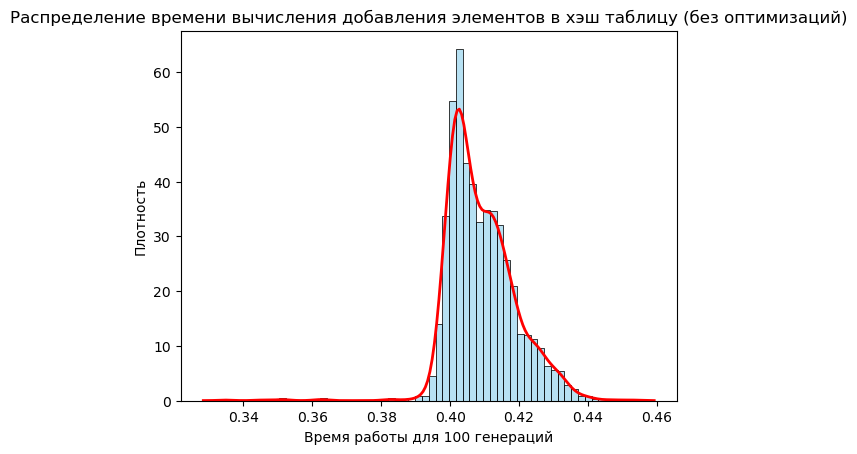

In [56]:
filtered = df[df.iloc[:,0] == "pgo"]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (без оптимизаций)")
plt.show()

In [57]:
filtered.describe()

,1
count,2000.000000
mean,0.409117
std,0.009691
min,0.334754
25%,0.402139
50%,0.407350
75%,0.414715
max,0.452825


In [58]:
mean = np.mean(filtered.iloc[:,1])
std = np.std(filtered.iloc[:,1], ddof=1)
n = len(filtered.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print(z * std / np.sqrt(n))

print("Доверительный интервал:")
print(lower, upper)

0.0004247047496750025
Доверительный интервал:
0.408692750750325 0.409542160249675


In [59]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(filtered.iloc[:,1], filtered0.iloc[:,1], alternative='two-sided')

print(f"U-статистика: {statistic}")
print(f"p-value: {p_value}")

U-статистика: 4346998.5
p-value: 2.994133570498386e-76


### Среднее время работы версии с оптимизацией в виде замены хэш функции 0.40 (+- 0.02) секунд

# Сравнение всех реализаций


| Реализаций | Время | Относительное ускорение  | Абсолютное ускорение |  Относительное ускорение в долях / (кол-во асм кода) * 100% |
|-------------|-------------| -------------|  -------------|  -------------|
| Без оптимизаций    | 0.41 (+- 0.01)    | 1  | 1 |  - |
| Оптимизация хэша    | 0.203 (+- 0.007)    | 1.90 | 1.90  |  - |
| Оптимизация  find_node  | 0.12 (+- 0.01)    | 1.65 | 3.15 |  10.89 % |
| Замена  strcmp   | 0.113 (+- 0.008)    | 1.15 | 3.64 |  2.58 % |
| pgo   | 0.40 (+- 0.01)    | - | - |  - |

Видим, что последняя оптимизация дала уже небольшое относительное ускорение  и хорошее абсолютное ускорение, следовательно стоит закончить оптимизировать хэш таблицы, так как дальнейшие оптмимизации усложнят понимание кода, но сильно код не ускорят.

# Доказательство отсутвия тротлинга при замерах

Каждый замер проводился 3 раза ( в каждом замере было 100 тестов), процесс был изолирован на 3(4, если нумеровать ядра с 1) ядре. Тактовая частота мной дополнительно не фиксировалась, но была стабильна на протяжении замеров.

In [89]:
df = pd.read_csv("control_freq/control.csv", sep=";", header=None)

In [82]:
filtered = df[df.iloc[:,0] == "run_opt_test0"].copy()

filtered[3] = pd.to_datetime(filtered[3].astype(str), format="%H-%M-%S")

filtered[3] = (filtered[3] - filtered[3].iloc[0]).dt.total_seconds()

#### Линейная регрессия тактовая частота для 1 теста 

                            OLS Regression Results                            
Dep. Variable:                      1   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     45.05
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           2.06e-11
Time:                        18:41:53   Log-Likelihood:                -85915.
No. Observations:                7197   AIC:                         1.718e+05
Df Residuals:                    7195   BIC:                         1.718e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.307e+06    871.085   2648.641      0.0

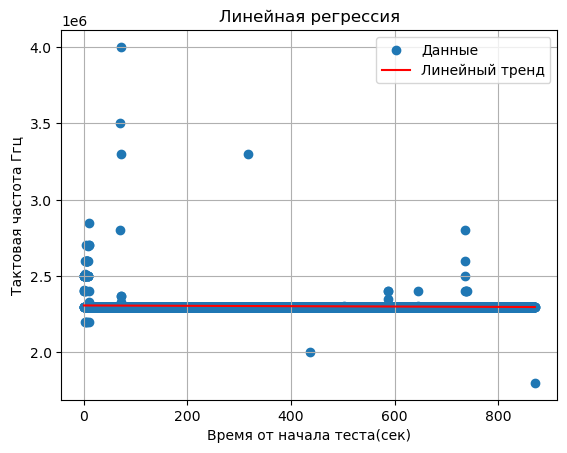

In [53]:
import statsmodels.api as sm
import numpy as np

Y = filtered.iloc[:, 1]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Тактовая частота Ггц")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [58]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

1.612306374299984


### Линейная регрессия температура (в миллиградусах) для 1 теста 

                            OLS Regression Results                            
Dep. Variable:                      2   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     2089.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:44:55   Log-Likelihood:                -61994.
No. Observations:                7197   AIC:                         1.240e+05
Df Residuals:                    7195   BIC:                         1.240e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.241e+04     31.375   1989.223      0.0

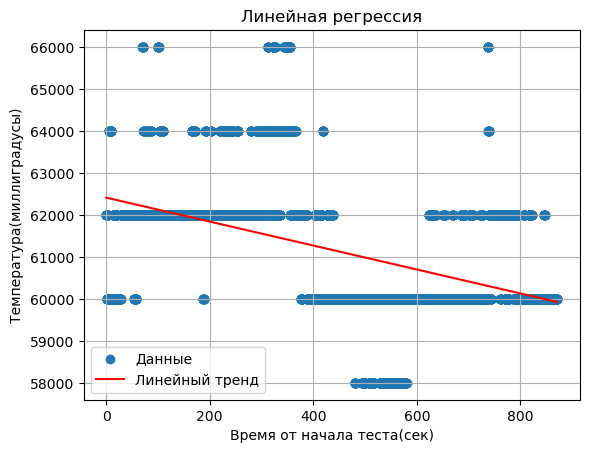

In [59]:
Y = filtered.iloc[:, 2]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Температура(миллиградусы)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [60]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

2.474899720133151


In [83]:
filtered = df[df.iloc[:,0] == "run_opt_test1"].copy()

filtered[3] = pd.to_datetime(filtered[3].astype(str), format="%H-%M-%S")

filtered[3] = (filtered[3] - filtered[3].iloc[0]).dt.total_seconds()

### Линейная регрессия тактовая частота 2 тест 

                            OLS Regression Results                            
Dep. Variable:                      1   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     15.83
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           7.09e-05
Time:                        18:45:19   Log-Likelihood:                -39885.
No. Observations:                3088   AIC:                         7.977e+04
Df Residuals:                    3086   BIC:                         7.979e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.318e+06   3538.717    655.119      0.0

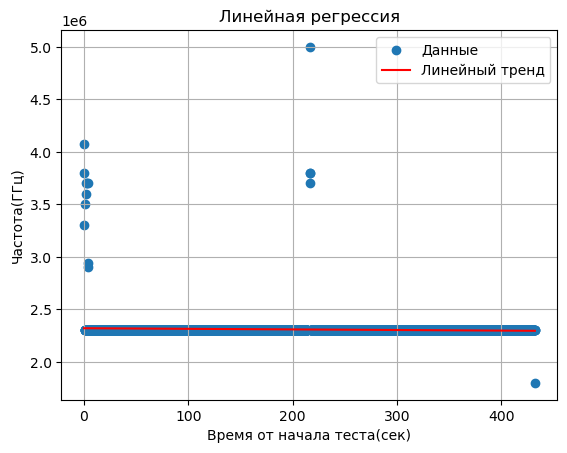

In [62]:
Y = filtered.iloc[:, 1]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Частота(ГГц)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

4.27981297763684


### Линейная регрессия температура 2 тест 

                            OLS Regression Results                            
Dep. Variable:                      2   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     845.4
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          1.74e-164
Time:                        18:45:41   Log-Likelihood:                -26633.
No. Observations:                3088   AIC:                         5.327e+04
Df Residuals:                    3086   BIC:                         5.328e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.447e+04     48.431   1331.188      0.0

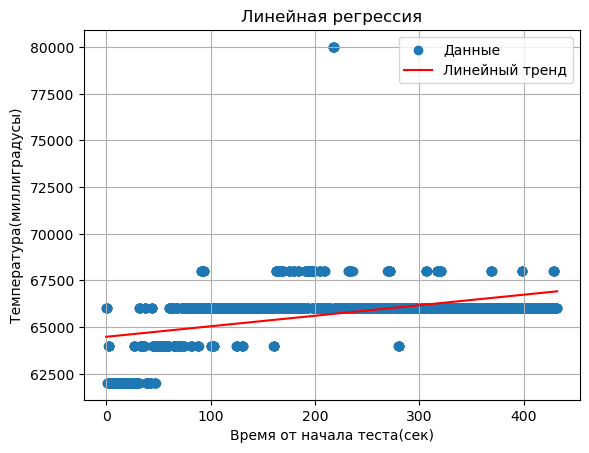

In [64]:
Y = filtered.iloc[:, 2]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Температура(миллиградусы)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [65]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

2.314975877396212


In [84]:
filtered = df[df.iloc[:,0] == "run_opt_test2"].copy()

filtered[3] = pd.to_datetime(filtered[3].astype(str), format="%H-%M-%S")

filtered[3] = (filtered[3] - filtered[3].iloc[0]).dt.total_seconds()

### Линейная регрессия тактовая частота 3 тест 

                            OLS Regression Results                            
Dep. Variable:                      1   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     10.80
Date:                Tue, 28 Apr 2026   Prob (F-statistic):            0.00104
Time:                        18:46:07   Log-Likelihood:                -22483.
No. Observations:                1690   AIC:                         4.497e+04
Df Residuals:                    1688   BIC:                         4.498e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.329e+06   7008.928    332.326      0.0

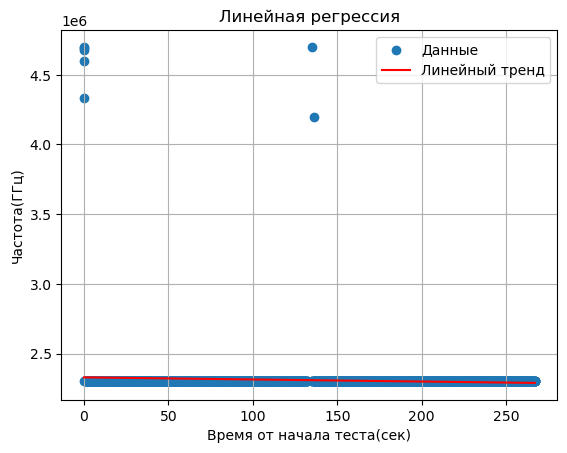

In [67]:
Y = filtered.iloc[:, 1]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Частота(ГГц)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [85]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

2.800184838242725


### Линейная регрессия температура 3 тест 

                            OLS Regression Results                            
Dep. Variable:                      2   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     10.01
Date:                Tue, 28 Apr 2026   Prob (F-statistic):            0.00158
Time:                        18:46:27   Log-Likelihood:                -14361.
No. Observations:                1690   AIC:                         2.873e+04
Df Residuals:                    1688   BIC:                         2.874e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.631e+04     57.343   1156.442      0.0

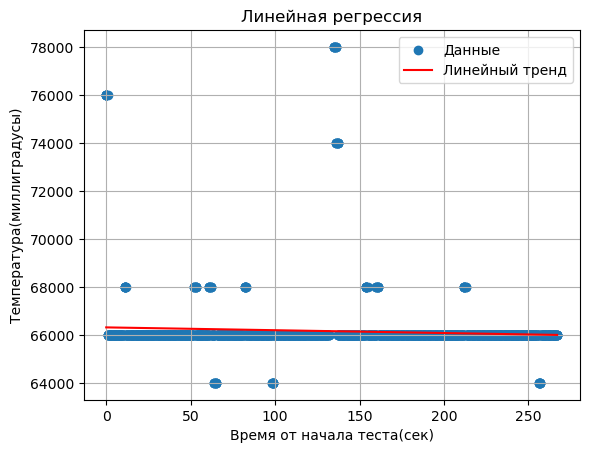

In [69]:
Y = filtered.iloc[:, 2]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Температура(миллиградусы)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [70]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

1.7996202220420892


In [91]:
filtered = df[df.iloc[:,0] == "run_opt_test3"].copy()

filtered[3] = pd.to_datetime(filtered[3].astype(str), format="%H-%M-%S")

filtered[3] = (filtered[3] - filtered[3].iloc[0]).dt.total_seconds()

### Линейная регрессия тактовая частота 4 тест

                            OLS Regression Results                            
Dep. Variable:                      1   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                 0.0001725
Date:                Tue, 28 Apr 2026   Prob (F-statistic):              0.990
Time:                        19:24:32   Log-Likelihood:                -17194.
No. Observations:                1389   AIC:                         3.439e+04
Df Residuals:                    1387   BIC:                         3.440e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.305e+06   3082.229    747.751      0.0

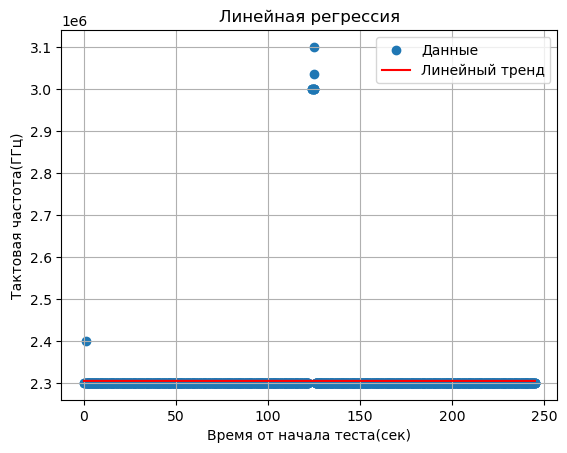

In [92]:
Y = filtered.iloc[:, 1]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Тактовая частота(ГГц)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [93]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

2.4956557741586995


### Линейная регрессия температура 4 тест 

                            OLS Regression Results                            
Dep. Variable:                      2   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4607
Date:                Tue, 28 Apr 2026   Prob (F-statistic):              0.497
Time:                        18:47:12   Log-Likelihood:                -12151.
No. Observations:                1389   AIC:                         2.431e+04
Df Residuals:                    1387   BIC:                         2.432e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.637e+04     81.685    812.532      0.0

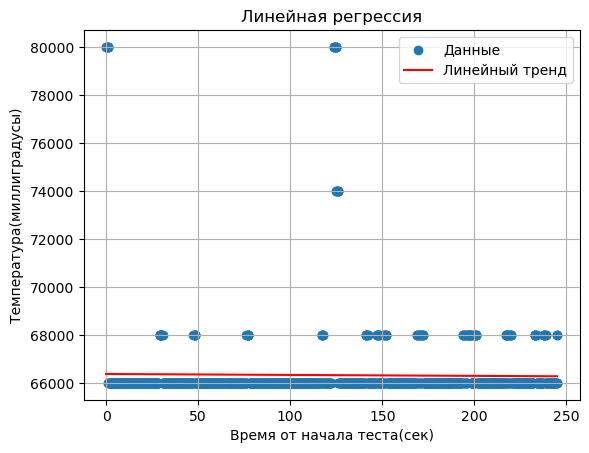

In [74]:
Y = filtered.iloc[:, 2]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Температура(миллиградусы)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [75]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

2.298693958836672


In [76]:
filtered = df[df.iloc[:,0] == "run_pgo_test2"].copy()

filtered[3] = pd.to_datetime(filtered[3].astype(str), format="%H-%M-%S")

filtered[3] = (filtered[3] - filtered[3].iloc[0]).dt.total_seconds()

### Линейная регрессия тактовая частота 5 тест 

                            OLS Regression Results                            
Dep. Variable:                      1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     4.005
Date:                Tue, 28 Apr 2026   Prob (F-statistic):             0.0454
Time:                        18:47:34   Log-Likelihood:                -56938.
No. Observations:                4462   AIC:                         1.139e+05
Df Residuals:                    4460   BIC:                         1.139e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.31e+06   2483.449    930.089      0.0

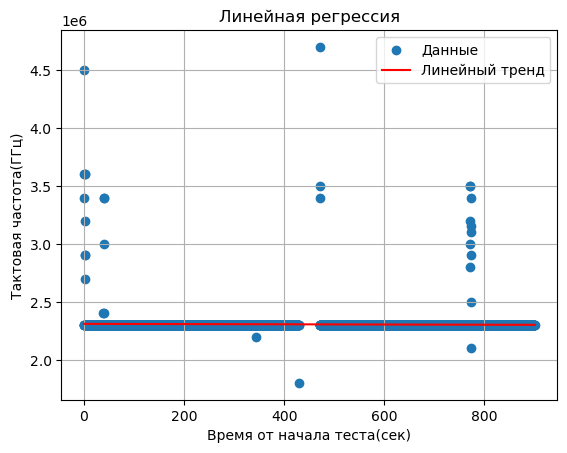

In [77]:
Y = filtered.iloc[:, 1]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Тактовая частота(ГГц)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()


In [78]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

3.657258589754352


### Линейная регрессия температура 5 тест 

                            OLS Regression Results                            
Dep. Variable:                      2   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     3086.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:47:58   Log-Likelihood:                -38556.
No. Observations:                4462   AIC:                         7.712e+04
Df Residuals:                    4460   BIC:                         7.713e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.168e+04     40.347   1528.665      0.0

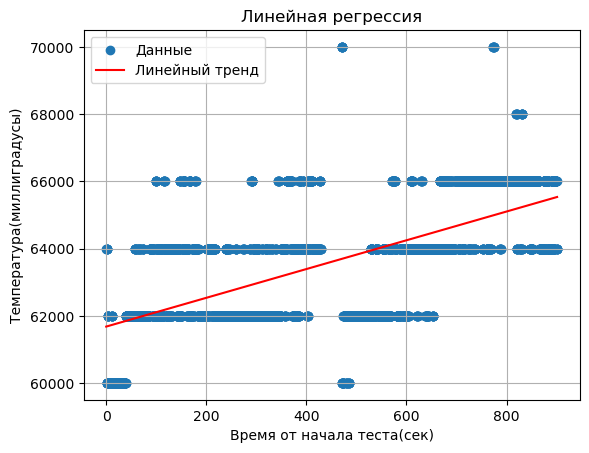

In [79]:
Y = filtered.iloc[:, 2]
x = filtered.iloc[:, 3]

X = sm.add_constant(x)
model = sm.OLS(Y,X)

results = model.fit()

Y_pred = results.predict(X)

print(results.summary())

plt.scatter(x, Y, label="Данные")
plt.plot(x, Y_pred, label="Линейный тренд", color="red")

plt.xlabel("Время от начала теста(сек)")
plt.ylabel("Температура(миллиградусы)")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)

plt.show()

In [80]:
Y.describe()

mean = Y.mean()
std = Y.std()

cv = std / mean

print(cv * 100)

2.800184838242725
